In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data.csv', index_col=0, header=0)

df = df.rename(columns = {'OvQual':'Overall Qual',
                          'Built':'Year',
                          'Garage Yr Built':'Year Garage'})

df = df.select_dtypes(include=np.number)
df = df.dropna(axis=0)
df = df.sample(50)

df = df.reset_index(drop=True)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Lot Frontage              50 non-null     float64
 1   Lot Area                  50 non-null     int64  
 2   Overall Qual              50 non-null     int64  
 3   Overall Cond              50 non-null     int64  
 4   Year                      50 non-null     int64  
 5   Year Remod Add            50 non-null     int64  
 6   Masonry/Veneer Area       50 non-null     float64
 7   Basement Finished Area    50 non-null     int64  
 8   Basement Unfinished Area  50 non-null     int64  
 9   Basement Area             50 non-null     int64  
 10  1st Floor Area            50 non-null     int64  
 11  2nd Floor Area            50 non-null     int64  
 12  Living Area Above Grade   50 non-null     int64  
 13  Basement Full Baths       50 non-null     int64  
 14  Basement Hal

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
0,75.0,9803,7,5,2005,2005,0.0,400,466,866,866,902,1768,0,0,2,1,3,1,7,0,2005.0,2,603,0,108,0,0,0,0,226700
1,63.0,7875,7,5,1995,1996,38.0,0,1237,1237,1253,0,1253,0,0,2,0,3,1,6,1,1995.0,2,402,220,21,0,0,0,0,176000
2,85.0,9350,5,8,1965,1999,0.0,633,586,1219,1265,0,1265,0,1,2,0,3,1,6,1,1965.0,2,502,0,92,0,96,0,0,179900
3,42.0,14892,9,5,2006,2007,160.0,1320,426,1746,1746,0,1746,1,0,2,0,3,1,7,2,2006.0,3,758,201,39,0,0,0,0,377500
4,57.0,8846,5,5,1996,1996,0.0,298,572,870,914,0,914,0,0,1,0,2,1,5,0,1998.0,2,576,0,0,0,0,0,0,148000


[1.         0.99995608 0.99993514 0.99995817 0.99981547 0.99939916
 0.99982899 0.99967478 0.99999049 0.9997984  0.99972493 0.99948925
 0.99995121 0.99996813 0.99946168 0.99999061 0.99979837 0.99987103
 0.9998792  0.99994936 0.99960814 0.99997433 0.99872451 0.99936533
 0.99959032 0.99993136 0.99972088 0.99987839 0.99991597 0.99992295
 0.99978442 0.99948921 0.99998866 0.99975681 0.99942478 0.99994769
 0.99996423 0.99965481 0.9997453  0.99995862 0.99996752 0.99989561
 0.99998591 0.99980537 0.99613089 0.99997469 0.99982911 0.99983925
 0.99970623 0.99953559]


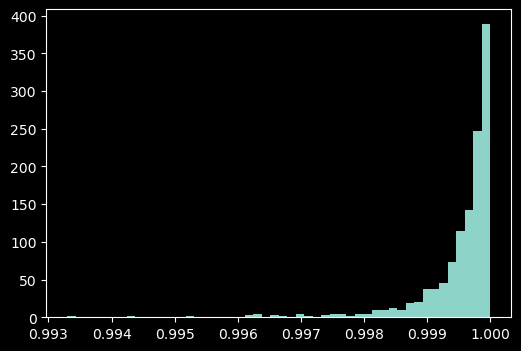

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(df)
print(cosine_sim[0,:])

idx = np.triu_indices(cosine_sim.shape[0], k=1)
cosine_sim_flat = cosine_sim[idx]
plt.figure(figsize=(6,4))
plt.hist(cosine_sim_flat, bins=50);

In [4]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

df_ss = pd.DataFrame()
for c in df.columns:
    df_ss[c] = std_scaler.fit_transform(df[[c]])[:,0]
# end

df_ss.head()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
0,0.468196,0.326356,0.488634,-0.516256,0.905580,0.756990,-0.549957,-0.104809,-0.298303,-0.615063,-0.811899,1.215287,0.501919,-0.922958,-0.204124,0.850963,1.277333,0.261488,-0.142857,0.306686,-0.928477,0.867122,0.204124,0.588704,-0.692125,1.522716,-0.36285,-0.200526,-0.283501,0.0,0.365847
1,-0.202252,-0.280759,0.488634,-0.516256,0.606511,0.295411,-0.331720,-1.064601,1.722360,0.377492,0.280304,-0.852058,-0.612831,-0.922958,-0.204124,0.850963,-0.782881,0.261488,-0.142857,-0.332243,0.928477,0.514634,0.204124,-0.518628,1.280253,-0.419752,-0.36285,-0.200526,-0.283501,0.0,-0.258787
2,1.026903,0.183709,-0.992076,3.003669,-0.290695,0.449271,-0.549957,0.454269,0.016197,0.329335,0.314170,-0.852058,-0.586856,-0.922958,4.898979,0.850963,-0.782881,0.261488,-0.142857,-0.332243,0.928477,-0.542833,0.204124,0.032283,-0.692125,1.165481,-0.36285,3.877970,-0.283501,0.0,-0.210738
3,-1.375536,1.928849,1.969344,-0.516256,0.935487,0.859564,0.368936,2.102711,-0.403137,1.739244,1.671662,-0.852058,0.454298,1.083473,-0.204124,0.850963,-0.782881,0.261488,-0.142857,0.306686,2.785430,0.902371,1.905159,1.442617,1.109911,-0.017862,-0.36285,-0.200526,-0.283501,0.0,2.223734
4,-0.537476,0.025003,-0.992076,-0.516256,0.636418,0.295411,-0.549957,-0.349556,-0.020495,-0.604361,-0.676432,-0.852058,-1.346617,-0.922958,-0.204124,-1.175139,-0.782881,-1.372813,-0.142857,-0.971172,-0.928477,0.620380,0.204124,0.439958,-0.692125,-0.888623,-0.36285,-0.200526,-0.283501,0.0,-0.603753


[ 1.         -0.178527   -0.10722576 -0.08528075 -0.06860222 -0.0536812
 -0.24208465  0.19486763  0.80859405 -0.27154014 -0.28558521 -0.40075871
  0.00425409  0.71419102 -0.24898707 -0.07297119 -0.06861925 -0.13416369
  0.15031765 -0.16343029 -0.15045948  0.54561654 -0.46106318 -0.03829478
 -0.11143276 -0.22988392 -0.26877558 -0.26766262 -0.35826065  0.26857468
 -0.19959464 -0.26489432  0.46742157 -0.34414226  0.05815421  0.34638061
  0.05000361  0.06959323 -0.1325578   0.56832592  0.26502675  0.11277865
  0.86502199 -0.43682465 -0.31761637  0.00662243  0.5044481  -0.40416673
 -0.13693962  0.2476721 ]


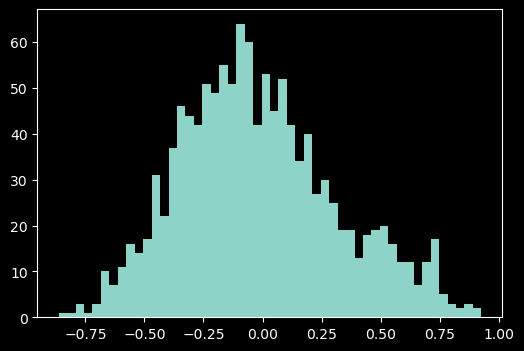

In [8]:
cosine_sim_ss = cosine_similarity(df_ss)
print(cosine_sim_ss[0,:])

idx = np.triu_indices(cosine_sim_ss.shape[0], k=1)
cosine_sim_ss_flat = cosine_sim_ss[idx]
plt.figure(figsize=(6,4))
plt.hist(cosine_sim_ss_flat, bins=50);

In [35]:
rows, cols = np.where(cosine_sim_ss > 0.75)
n_found = rows.shape[0]
print(n_found)

for i, (r, c) in enumerate(zip(rows, cols)):
    if r != c:
        display(df.iloc[[r,c],:])

74


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
1,77.0,9965,8,5,2006,2007,340.0,1150,316,1466,1466,1362,2828,1,0,3,0,4,1,11,1,2006.0,3,1052,125,144,0,0,0,0,424870
21,110.0,13688,9,5,2003,2004,664.0,1016,556,1572,1572,1096,2668,1,0,2,1,3,1,10,2,2003.0,3,726,400,0,0,0,0,0,412500


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
1,77.0,9965,8,5,2006,2007,340.0,1150,316,1466,1466,1362,2828,1,0,3,0,4,1,11,1,2006.0,3,1052,125,144,0,0,0,0,424870
38,67.0,14948,9,5,2008,2008,268.0,1330,122,1452,1476,1237,2713,1,0,2,1,3,1,11,1,2008.0,3,858,126,66,0,0,0,0,446261


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
9,85.0,9187,9,5,2009,2009,162.0,1121,645,1766,1766,0,1766,1,0,2,1,2,1,7,1,2009.0,3,478,195,130,0,0,0,0,370878
25,60.0,7313,9,5,2005,2005,246.0,1153,408,1561,1561,0,1561,1,0,2,0,2,1,6,1,2005.0,2,556,203,47,0,0,0,0,277500


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
11,21.0,1680,6,8,1972,2007,510.0,162,321,483,483,504,987,0,0,1,1,2,1,5,0,1972.0,1,264,250,0,0,0,0,0,118000
26,21.0,1869,6,6,1970,1970,127.0,321,162,483,483,504,987,0,0,1,1,2,1,5,0,1987.0,1,280,0,0,0,0,0,0,106000


...

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
44,68.0,7820,9,5,2007,2007,362.0,0,1869,1869,1869,0,1869,0,0,2,0,2,1,6,1,2007.0,2,617,210,54,0,0,0,0,318061
35,63.0,8500,7,5,2004,2004,106.0,0,1422,1422,1422,0,1422,0,0,2,0,3,1,7,0,2004.0,2,626,192,60,0,0,0,0,179600


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
44,68.0,7820,9,5,2007,2007,362.0,0,1869,1869,1869,0,1869,0,0,2,0,2,1,6,1,2007.0,2,617,210,54,0,0,0,0,318061
36,110.0,14230,8,5,2007,2007,640.0,0,1566,1566,1600,0,1600,0,0,2,0,3,1,7,1,2007.0,3,890,0,56,0,0,0,0,256300


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
46,52.0,5825,4,5,1926,1953,108.0,0,600,600,747,0,747,0,0,1,0,1,1,5,0,1953.0,2,528,0,0,32,0,0,0,79900
48,60.0,7200,4,5,1950,1950,0.0,0,0,0,1040,0,1040,0,0,1,0,2,1,4,0,1950.0,2,420,0,29,0,0,0,0,109900


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
48,60.0,7200,4,5,1950,1950,0.0,0,0,0,1040,0,1040,0,0,1,0,2,1,4,0,1950.0,2,420,0,29,0,0,0,0,109900
46,52.0,5825,4,5,1926,1953,108.0,0,600,600,747,0,747,0,0,1,0,1,1,5,0,1953.0,2,528,0,0,32,0,0,0,79900


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
49,70.0,13300,5,7,1956,2000,0.0,377,551,928,928,0,928,0,0,1,0,2,1,4,0,1956.0,1,252,261,0,156,0,0,0,132000
14,68.0,9717,5,6,1950,1996,0.0,49,0,1078,1078,0,1078,1,0,1,0,2,1,5,0,1950.0,1,240,366,0,112,0,0,0,142125
